# Customer Segmentation — RFM Analysis & KMeans Clustering
**Online Retail II (UCI) · Dec 2009 – Dec 2010 · UK online gift retailer**

Goal: turn raw transactions into named customer segments, each with a marketing action.

Pipeline: `raw Excel → clean → RFM features → scale → KMeans (+ outlier groups) → 7 segments → recommendations`

**Before running:** download `online_retail_II.xlsx` from the [UCI repository](https://archive.ics.uci.edu/dataset/502/online+retail+ii) and place it at `./data/online_retail_II.xlsx`.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import os

sns.set_style("whitegrid")
os.makedirs("images", exist_ok=True)
RANDOM_STATE = 42

## 1. Load the raw data

In [2]:
df = pd.read_excel("./data/online_retail_II.xlsx", sheet_name=0)
print("Raw shape:", df.shape)
df.head()

Raw shape: (525461, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


### Quick profile
Look at types, missing values, and the suspicious stuff (negative quantities = returns, missing Customer ID, odd invoice/stock-code formats).

In [3]:
df.info()
print("\nMissing Customer ID:", df["Customer ID"].isna().sum())
print("Negative-quantity rows:", (df["Quantity"] < 0).sum())
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 32.1+ MB

Missing Customer ID: 107927
Negative-quantity rows: 12326


,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845018,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [4]:
# Invoice prefixes: C = cancellation, A = admin write-off
df["Invoice"] = df["Invoice"].astype(str)
print("Non-numeric invoice prefixes:",
      df.loc[~df["Invoice"].str.match(r"^\d+$"), "Invoice"].str[0].unique())

Non-numeric invoice prefixes: <StringArray>
['C', 'A']
Length: 2, dtype: str


## 2. Data cleaning
Every removal is deliberate and documented. We keep only **real orders** (6-digit numeric invoices) and **real products** (proper stock-code formats), then drop rows we can't use.

In [5]:
cleaned_df = df.copy()
n0 = len(cleaned_df)

# Keep only valid 6-digit numeric invoices -> drops C (cancellations) and A (admin)
cleaned_df["Invoice"] = cleaned_df["Invoice"].astype(str)
cleaned_df = cleaned_df[cleaned_df["Invoice"].str.match(r"^\d{6}$") == True]
n_inv = len(cleaned_df)

# Keep only real product stock codes -> drops POST, DOT, bank charges, etc.
cleaned_df["StockCode"] = cleaned_df["StockCode"].astype(str)
prod_mask = (
    (cleaned_df["StockCode"].str.match(r"^\d{5}$") == True)
    | (cleaned_df["StockCode"].str.match(r"^\d{5}[a-zA-Z]+$") == True)
    | (cleaned_df["StockCode"].str.match(r"^PADS$") == True)
)
cleaned_df = cleaned_df[prod_mask]
n_stock = len(cleaned_df)

# Drop rows with no Customer ID (can't attribute to a customer)
cleaned_df = cleaned_df.dropna(subset=["Customer ID"])
n_cust = len(cleaned_df)

# Drop zero / negative price rows
cleaned_df = cleaned_df[cleaned_df["Price"] > 0.0]
n_price = len(cleaned_df)

print(f"Start:                 {n0:>8,}")
print(f"After invoice filter:  {n_inv:>8,}  (-{n0-n_inv:,})")
print(f"After stock filter:    {n_stock:>8,}  (-{n_inv-n_stock:,})")
print(f"After dropna ID:       {n_cust:>8,}  (-{n_stock-n_cust:,})")
print(f"After price>0:         {n_price:>8,}  (-{n_cust-n_price:,})")
print(f"\nRetained: {n_price:,} rows = {n_price/n0:.1%} of original")

Start:                  525,461
After invoice filter:   515,252  (-10,209)
After stock filter:     512,796  (-2,456)
After dropna ID:        406,337  (-106,459)
After price>0:          406,309  (-28)

Retained: 406,309 rows = 77.3% of original


## 3. Feature engineering — the RFM model
Collapse every transaction into **one row per customer**:
- **Recency** — days since their last purchase
- **Frequency** — number of distinct orders
- **Monetary** — total spend

In [6]:
cleaned_df["SalesLineTotal"] = cleaned_df["Quantity"] * cleaned_df["Price"]

rfm = cleaned_df.groupby("Customer ID", as_index=False).agg(
    MonetaryValue   = ("SalesLineTotal", "sum"),
    Frequency       = ("Invoice", "nunique"),
    LastInvoiceDate = ("InvoiceDate", "max"),
)

snapshot = rfm["LastInvoiceDate"].max()
rfm["Recency"] = (snapshot - rfm["LastInvoiceDate"]).dt.days
print("Customers:", len(rfm))
rfm.head()

Customers: 4285


,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
0,12346.0,169.36,2,2010-06-28 13:53:00,164
1,12347.0,1323.32,2,2010-12-07 14:57:00,2
2,12348.0,221.16,1,2010-09-27 14:59:00,73
3,12349.0,2221.14,2,2010-10-28 08:23:00,42
4,12351.0,300.93,1,2010-11-29 15:23:00,10


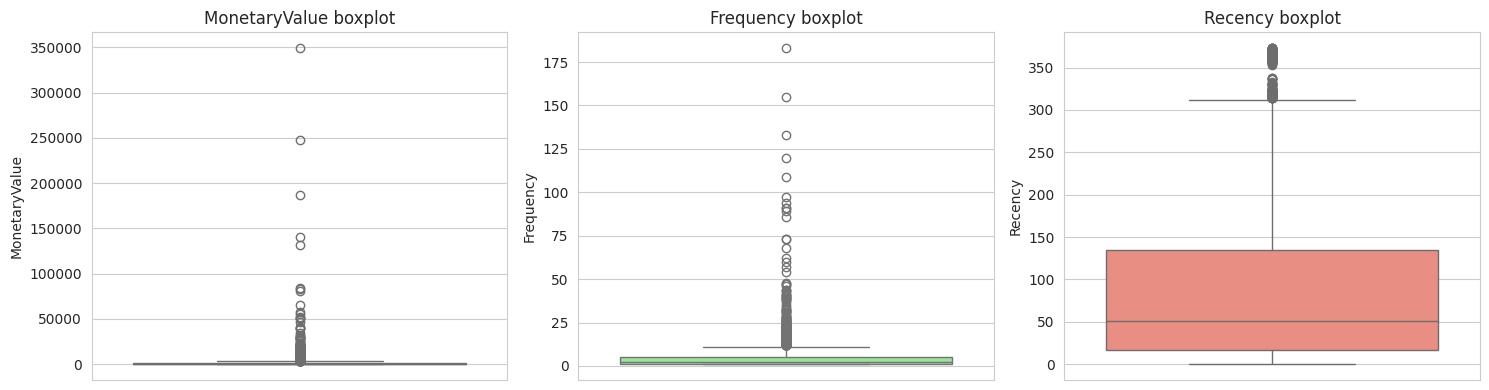

In [7]:
# Distributions
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, col, color in zip(ax, ["MonetaryValue", "Frequency", "Recency"],
                         ["skyblue", "lightgreen", "salmon"]):
    sns.boxplot(y=rfm[col], ax=a, color=color)
    a.set_title(f"{col} boxplot")
plt.tight_layout(); plt.savefig("images/rfm_boxplots.png", dpi=120, bbox_inches="tight"); plt.show()

## 4. Outlier handling (IQR)
A few enterprise-scale buyers would drag the cluster centres away from the typical customer. We **split them out** using the IQR rule on Monetary and Frequency — then segment them separately rather than deleting them (they're the most valuable customers).

In [8]:
def iqr_outliers(frame, col):
    q1, q3 = frame[col].quantile(0.25), frame[col].quantile(0.75)
    iqr = q3 - q1
    return frame[(frame[col] > q3 + 1.5*iqr) | (frame[col] < q1 - 1.5*iqr)]

monetary_outliers = iqr_outliers(rfm, "MonetaryValue")
frequency_outliers = iqr_outliers(rfm, "Frequency")

non_outliers = rfm[(~rfm.index.isin(monetary_outliers.index)) &
                   (~rfm.index.isin(frequency_outliers.index))].copy()

print("Total:", len(rfm),
      "| non-outliers:", len(non_outliers),
      "| monetary outliers:", len(monetary_outliers),
      "| frequency outliers:", len(frequency_outliers))

Total: 4285 | non-outliers: 3809 | monetary outliers: 423 | frequency outliers: 279


## 5. Scale the features
KMeans uses distance, so features must be on the same scale — otherwise Monetary (£thousands) would dominate Frequency (single digits).

In [9]:
features = ["MonetaryValue", "Frequency", "Recency"]
scaler = StandardScaler()
scaled = scaler.fit_transform(non_outliers[features])
scaled_df = pd.DataFrame(scaled, index=non_outliers.index, columns=features)
scaled_df.describe().round(2)

,MonetaryValue,Frequency,Recency
count,3809.00,3809.00,3809.00
mean,0.00,-0.00,0.00
std,1.00,1.00,1.00
min,-1.08,-0.83,-0.99
25%,-0.74,-0.83,-0.77
50%,-0.36,-0.38,-0.40
75%,0.47,0.51,0.58
max,3.55,3.63,2.81


## 6. Choose k — elbow + silhouette

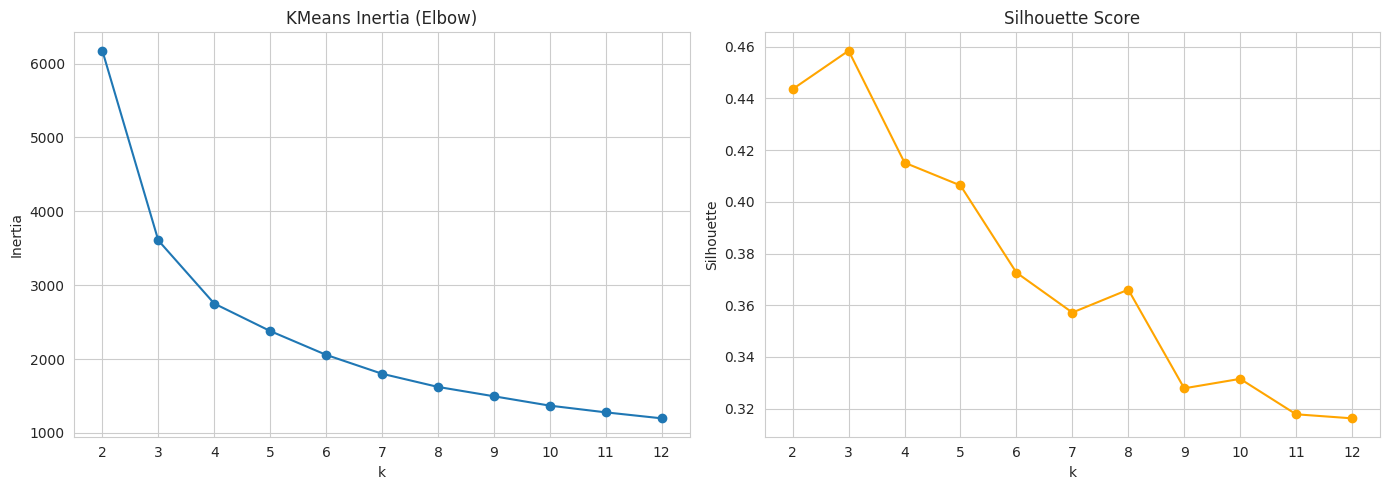

Best silhouette at k = 3 (0.458)


In [10]:
max_k = 12
ks = range(2, max_k + 1)
inertia, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, max_iter=1000, n_init=10)
    labels = km.fit_predict(scaled_df)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(scaled_df, labels))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(list(ks), inertia, "o-"); ax[0].set_title("KMeans Inertia (Elbow)")
ax[0].set_xlabel("k"); ax[0].set_ylabel("Inertia"); ax[0].set_xticks(list(ks))
ax[1].plot(list(ks), sil, "o-", color="orange"); ax[1].set_title("Silhouette Score")
ax[1].set_xlabel("k"); ax[1].set_ylabel("Silhouette"); ax[1].set_xticks(list(ks))
plt.tight_layout(); plt.savefig("images/silhouette_score.png", dpi=120, bbox_inches="tight"); plt.show()

print("Best silhouette at k =", list(ks)[int(np.argmax(sil))], f"({max(sil):.3f})")

### Why k = 4 (honest note)
Silhouette **peaks at k = 3** and the elbow bends around 3–4. I still choose **k = 4** on purpose: at k = 3 the loyal regulars and the new-quiet buyers merge into one group you can't write separate campaigns for. With 4 KMeans clusters + 3 outlier groups, every segment maps to a *distinct* marketing action — a small metric cost for a big gain in usefulness.

## 7. Fit KMeans with k = 4

In [11]:
kmeans = KMeans(n_clusters=4, random_state=RANDOM_STATE, max_iter=1000, n_init=10)
non_outliers["Cluster"] = kmeans.fit_predict(scaled_df)
non_outliers.groupby("Cluster")[features].mean().round(0)

,MonetaryValue,Frequency,Recency
Cluster,,,
0,1303.0,4.0,50.0
1,2426.0,7.0,34.0
2,414.0,2.0,54.0
3,385.0,1.0,251.0


Map cluster numbers to names by reading the profile above:
- highest spend + frequent + recent → **REWARD**
- solid repeat, mid values → **RETAIN**
- low value, low freq, recent → **NURTURE**
- one purchase, very stale (high recency) → **RE-ENGAGE**

> ⚠️ KMeans cluster *numbers* can change between runs/library versions. Check the profile table and adjust the mapping below if needed.

In [12]:
kmeans_labels = {0: "RETAIN", 1: "RE-ENGAGE", 2: "NURTURE", 3: "REWARD"}
non_outliers["ClusterLabel"] = non_outliers["Cluster"].map(kmeans_labels)

## 8. Segment the outliers separately
- **DELIGHT** — extreme on *both* spend and frequency (elite)
- **PAMPER** — big spenders only
- **UPSELL** — very frequent only (lower spend per order)

In [13]:
overlap = monetary_outliers.index.intersection(frequency_outliers.index)
monetary_only = monetary_outliers.index.difference(frequency_outliers.index)
frequency_only = frequency_outliers.index.difference(monetary_outliers.index)

out = rfm.loc[overlap.union(monetary_only).union(frequency_only)].copy()
out["ClusterLabel"] = np.where(out.index.isin(overlap), "DELIGHT",
                       np.where(out.index.isin(monetary_only), "PAMPER", "UPSELL"))
out["Cluster"] = out["ClusterLabel"].map({"DELIGHT": -3, "PAMPER": -1, "UPSELL": -2})
out.groupby("ClusterLabel")[features].mean().round(0)

,MonetaryValue,Frequency,Recency
ClusterLabel,,,
DELIGHT,17148.0,26.0,14.0
PAMPER,6498.0,7.0,48.0
UPSELL,2735.0,15.0,23.0


## 9. Combine into one labelled table

In [14]:
full = pd.concat([non_outliers, out])
print("Total customers labelled:", len(full))
full["ClusterLabel"].value_counts()

Total customers labelled: 4285


ClusterLabel
NURTURE      1487
RETAIN        921
REWARD        902
RE-ENGAGE     499
DELIGHT       226
PAMPER        197
UPSELL         53
Name: count, dtype: int64

## 10. Segment summary + revenue concentration

In [15]:
summary = (full.groupby("ClusterLabel")
           .agg(Customers=("MonetaryValue", "size"),
                AvgSpend=("MonetaryValue", "mean"),
                AvgOrders=("Frequency", "mean"),
                AvgRecency=("Recency", "mean"),
                TotalRevenue=("MonetaryValue", "sum"))
           .round(0))
summary["%Customers"] = (100*summary["Customers"]/summary["Customers"].sum()).round(1)
summary["%Revenue"]   = (100*summary["TotalRevenue"]/summary["TotalRevenue"].sum()).round(1)
summary = summary.sort_values("TotalRevenue", ascending=False)
summary

,Customers,AvgSpend,AvgOrders,AvgRecency,TotalRevenue,%Customers,%Revenue
ClusterLabel,,,,,,,
DELIGHT,226,17148.0,26.0,14.0,3875372.0,5.3,44.7
PAMPER,197,6498.0,7.0,48.0,1280195.0,4.6,14.8
RE-ENGAGE,499,2426.0,7.0,34.0,1210756.0,11.6,14.0
RETAIN,921,1303.0,4.0,50.0,1200217.0,21.5,13.8
NURTURE,1487,414.0,2.0,54.0,615053.0,34.7,7.1
REWARD,902,385.0,1.0,251.0,346852.0,21.1,4.0
UPSELL,53,2735.0,15.0,23.0,144938.0,1.2,1.7


In [16]:
elite = ["DELIGHT", "PAMPER", "UPSELL"]
print(f"Elite segments = {summary.loc[elite,'%Customers'].sum():.1f}% of customers "
      f"but {summary.loc[elite,'%Revenue'].sum():.1f}% of revenue")
print(f"DELIGHT alone = {summary.loc['DELIGHT','%Customers']:.1f}% of customers, "
      f"{summary.loc['DELIGHT','%Revenue']:.1f}% of revenue")

Elite segments = 11.1% of customers but 61.2% of revenue
DELIGHT alone = 5.3% of customers, 44.7% of revenue


## 11. Cluster distribution chart

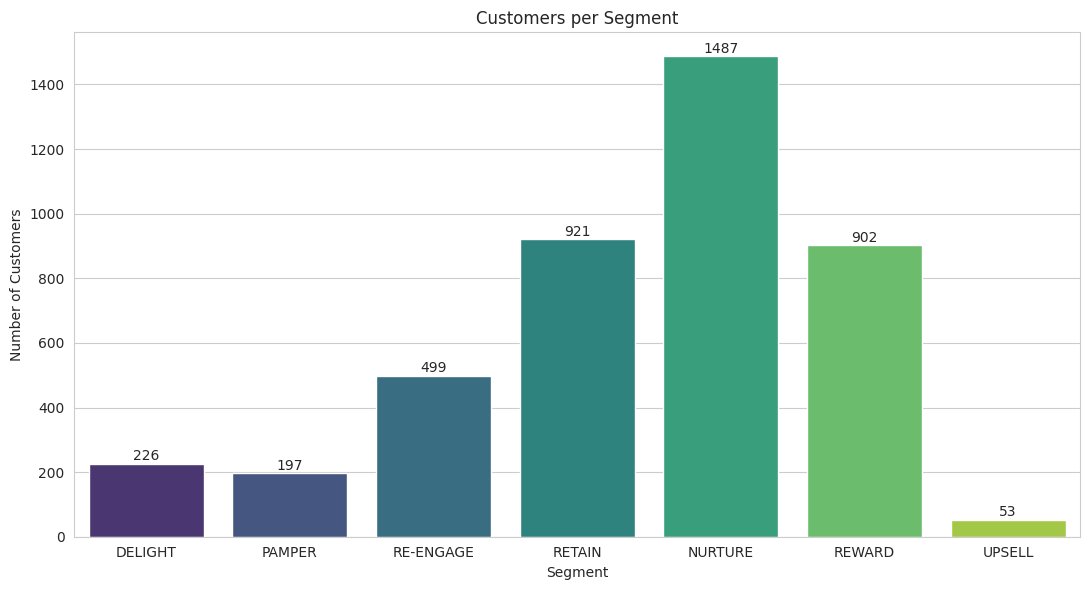

In [17]:
order = summary.index.tolist()
plt.figure(figsize=(11, 6))
sns.barplot(x=summary.loc[order].index, y=summary.loc[order, "Customers"],
            hue=summary.loc[order].index, palette="viridis", legend=False)
plt.title("Customers per Segment"); plt.xlabel("Segment"); plt.ylabel("Number of Customers")
for i, v in enumerate(summary.loc[order, "Customers"]):
    plt.text(i, v+10, int(v), ha="center")
plt.tight_layout(); plt.savefig("images/cluster_distribution.png", dpi=120, bbox_inches="tight"); plt.show()

## 12. Recommendations

| Segment | Action |
|---|---|
| DELIGHT | Dedicated account management — protect the ~45% of revenue they drive |
| PAMPER | Premium / concierge treatment |
| REWARD | VIP loyalty programme |
| UPSELL | Bundles & cross-sell to raise basket size |
| RETAIN | Keep-warm loyalty offers |
| NURTURE | Onboarding & education to build the habit |
| RE-ENGAGE | Time-boxed win-back offers; deprioritise if no response |

**Headline:** revenue is concentrated in ~11% of customers. A flat marketing budget under-serves them — segment-specific spend is the opportunity.